# 고양이 수염 스티커 카메라앱 만들기 (CV01)

dlib 으로 얼굴을 찾고 랜드마크(눈·코·입 68점)를 검출한 다음, 코 위에 고양이 수염 스티커를 합성하는 카메라앱을 직접 만들어 봤다.

아이펠 노드 학습에서는 **왕관**을 이마에 올렸는데, 이번엔 **고양이 수염**을 코에 올리는 버전이다. 뼈대는 같고, 딱 두 군데만 바꾼다(아래에서 자세히).

## 전체 흐름 (오늘 만들 것의 지도)

```
인물 사진  ->  ① 얼굴 찾기        (얼굴이 사진 어디 있나? 네모 박스)
         ->  ② 랜드마크 찾기   (눈·코·입 68개 점 콕콕 찍기)
         ->  ③ 코 위치 계산     (수염을 어디 올릴지 좌표 계산)
         ->  ④ 스티커 합성       (수염 그림을 그 위에 덮기)
```

마지막 Step 5 에서는 이 앱을 여러 사진(각도·밝기·거리 다르게)에 적용해 보고, **어떤 경우에 왜 깨지는지**를 체계적으로 정리했다.


## 0. 먼저 개념부터 — 내가 이해한 핵심 6가지

주요 개념을 내 말로 적어둔다. 나중에 이 노트북만 다시 봐도 이해되게 하려고.

1. **이미지 = 숫자 격자**: 사진 한 장은 `(세로, 가로, 색3)` 모양의 숫자 덩어리(ndarray)다.  
   각 픽셀은 0~255. 그리고 OpenCV(cv2)는 색을 **BGR(파랑-초록-빨강)** 순서로 읽는다(보통의 RGB와 반대).  
   그래서 `plt`로 그릴 땐 `cv2.cvtColor(img, COLOR_BGR2RGB)`로 순서를 바꿔야 사람 얼굴이 파랗게 안 나온다.  
   좌표는 **좌상단이 (0,0)**, x는 오른쪽으로 +, y는 **아래로** + 다.

2. **얼굴 검출(HOG)**: `dlib.get_frontal_face_detector()`로 탐지기를 꺼내 사진을 넣으면, 얼굴마다 네모 박스를 담은 **리스트**(바구니)를 돌려준다.  
   얼굴이 0명이면 빈 바구니라 `for`문이 안 돌아 스티커가 안 붙는다.  
   박스 하나는 `left()/top()`(왼쪽위), `right()/bottom()`(오른쪽아래)로 꺼낸다. 인자 `1`은 사진을 키워 다시 찾는 횟수(작은 얼굴을 더 잘 잡지만 느려진다).

3. **랜드마크 68점**: `shape_predictor` 모델로 얼굴 안에 점 68개를 찍는다.  
   번호가 약속돼 있다 — `0~16` 턱, `17~26` 눈썹, `27~35` 코, `36~47` 눈, `48~67` 입. 코 밑 한가운데가 **33번**이라, 수염 중심으로 33번을 썼다.

4. **위치 계산**: 코 점을 스티커의 **중심**으로 삼고, 거기서 폭·높이의 절반을 빼서 스티커의 **왼쪽위 모서리**(`refined_x`, `refined_y`)를 구한다.  
   그림은 왼쪽위부터 채워지기 때문이다.

5. **음수 보정**: 모서리가 음수면 사진 경계 밖이다(ndarray는 음수칸이 없다).  
   삐져나간 만큼 스티커를 잘라내고 시작점을 0으로 당긴다.

6. **np.where 합성(★ 함정)**: 스티커는 네모라 배경까지 같이 덮으면 안 된다. `np.where(조건, 원본, 스티커)`로 "배경 픽셀은 원본을 살리고, 그림 픽셀만 덮는다".  
   이건 진짜 투명(알파)이 아니라 **크로마키(초록 스크린)처럼 특정 색을 투명 취급**하는 것이다.  
   노드 왕관은 배경이 검정(0)이라 `==0`을 썼지만, **고양이 수염은 배경이 흰색(255)** 이라 조건을 `==255`로 뒤집어야 한다.

> **노드(왕관) → 내 프로젝트(수염) 바꾼 곳 딱 2군데**
> 1. 위치: 왕관처럼 위로 끌어올리지 않고 코(33번) 자리에 둔다.
> 2. 합성 조건: `np.where(...==0...)` 를 `np.where(...==255...)` 로 뒤집는다 (배경색이 반대라서).


## 1. 라이브러리 준비

오늘 쓸 라이브러리 버전을 먼저 확인.  
컴퓨터 비전은 `cv2`(OpenCV), 얼굴 검출·랜드마크는 `dlib`, 숫자 격자 다루기는 `numpy`, 그림 그리기는 `matplotlib`을 쓴다.

In [157]:
# [셀 목적] 이 노트북에서 쓸 도구(라이브러리)들을 불러온다. import = "이 도구를 갖다 쓰겠다".
import os                        # 파일 경로를 만들고 다루는 도구 (os.path.join 등)
import cv2                       # OpenCV - 이미지를 읽고/그리고/합성하는 컴퓨터 비전 도구
import dlib                      # 얼굴 검출 + 랜드마크(68점) 검출 도구
import numpy as np               # 숫자 격자(=이미지) 다루는 도구. 이름이 길어 별명 np 로 부른다
import matplotlib.pyplot as plt  # 이미지를 화면에 그려주는 도구. 별명 plt

# matplotlib 은 기본 폰트에 한글이 없어 제목이 □(두부)로 깨진다. 한글 폰트를 지정해 해결한다.
plt.rcParams['font.family'] = 'NanumGothic'   # 모든 그래프 글자를 나눔고딕으로
plt.rcParams['axes.unicode_minus'] = False    # 마이너스 기호(-) 도 안 깨지게

# 라이브러리 버전 확인 (버전에 따라 동작이 달라 기록해 둔다. dlib/numpy 충돌도 여기서 드러난다)
print('cv2 :', cv2.__version__)
print('dlib:', dlib.__version__)
import numpy as _np; print('numpy:', _np.__version__)   # numpy 버전도 같이 확인

cv2 : 4.13.0
dlib: 20.0.1
numpy: 2.5.0


> **환경 메모(내가 막혔던 것 기록)**:  
> 처음에 얼굴 검출에서 `Unsupported image type` 에러가 났다.  
> 알고 보니 기존 `dlib 19.24.2`(numpy 1.x 시절 빌드)가 지금 `numpy 2.5`와 충돌하는 거였다.  
> 깨끗한 빈 배열을 넣어도 같은 에러라 파일 문제가 아니라 환경 문제였다.  
> numpy 를 낮추면 opencv(numpy>=2 요구)가 깨져서, **dlib 만 20.0.1 로 다시 설치**해 해결했다.  
> ("돌아가던 게 갑자기 안 되면 라이브러리 버전 충돌부터 의심" 이라는 걸 배웠다.)


### 1b. 랜드마크 모델 준비

얼굴에 점 68개를 찍는 모델 파일(`shape_predictor_68_face_landmarks.dat`)이 필요하다.  
용량이 커서(96MB) 깃허브 repo 엔 올리지 않았고, 없으면 자동으로 받아오게 했다(있으면 건너뜀).

In [158]:
# [셀 목적] 얼굴에 점 68개를 찍는 모델 파일이 없으면 인터넷에서 받아온다 (있으면 그냥 넘어감).
import urllib.request, bz2                      # urllib=인터넷 다운로드, bz2=압축 풀기 도구
# 모델이 있어야 할 경로를 만든다: 지금 폴더(getcwd)/models/그모델.dat
model_path = os.path.join(os.getcwd(), 'models', 'shape_predictor_68_face_landmarks.dat')
if not os.path.exists(model_path):              # 그 파일이 아직 없다면(처음 실행) 아래를 한다
    os.makedirs(os.path.dirname(model_path), exist_ok=True)   # models 폴더가 없으면 만든다
    print('모델이 없어 다운로드한다...')
    bz2_path = model_path + '.bz2'              # 받을 때는 .bz2 로 압축된 채 온다
    urllib.request.urlretrieve(                 # 그 주소에서 파일을 내려받아 bz2_path 에 저장
        'http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2', bz2_path)
    with bz2.open(bz2_path) as fin, open(model_path, 'wb') as fout:   # 압축본 열고, 풀 파일 만들고
        fout.write(fin.read())          # bz2 압축을 풀어 .dat 로 저장 ('wb'=바이너리 쓰기)
    os.remove(bz2_path)                         # 압축본(.bz2)은 이제 필요 없으니 지운다
    print('다운로드 완료')
else:                                           # 파일이 이미 있으면 (두번째부터) 그냥 알림만
    print('모델 이미 있음:', model_path)

모델 이미 있음: /home/gmw/Documents/AIFFEL_Work/AIFFEL_Quest_eng/03_Computer_Vision/CV01/models/shape_predictor_68_face_landmarks.dat


## 2. 인물 사진 불러오기

기준이 되는 정면 인물 사진(`images/front.png`)을 불러왔다. 내 얼굴 대신, 라이선스 문제가 없는 캔바 프로의 실제 인물 사진을 썼다.  
cv2 는 이미지를 BGR 순서로 읽기 때문에, `plt`로 보려면 RGB 로 바꿔야 색이 제대로 나온다(개념 1).

이미지 shape (세로, 가로, 색): (1055, 1200, 3)


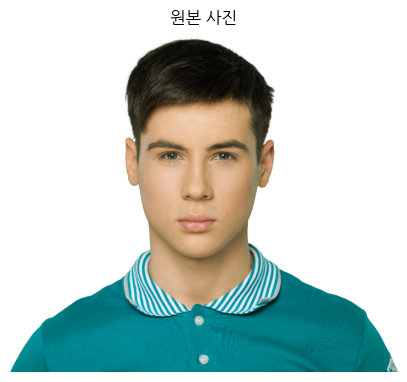

In [159]:
# [셀 목적] 기준이 될 인물 사진(front.png)을 읽어 화면에 띄운다.
# os.path.join(폴더, 폴더, 파일) = OS에 맞게 경로를 안전하게 이어붙인다 (윈도/리눅스 구분자 자동)
my_image_path = os.path.join(os.getcwd(), 'images', 'front.png')   # 지금폴더/images/front.png

img_bgr = cv2.imread(my_image_path)   # 사진을 읽는다. cv2 는 색을 BGR 순서의 (세로,가로,3) 숫자격자로 준다
print('이미지 shape (세로, 가로, 색):', img_bgr.shape)  # 숫자 격자 모양 확인 (예: (1055,1200,3))

# cv2 는 BGR 인데 plt 는 RGB 로 그려서, 안 바꾸면 빨강·파랑이 뒤바뀌어 얼굴이 파래진다 -> 순서 변환
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(5,5))   # 그림 한 장 준비 (크기 5x5인치)
plt.imshow(img_rgb)         # 그릴 이미지를 올린다 (아직 화면엔 안 나옴)
plt.title('원본 사진')      # 제목
plt.axis('off')             # 눈금(축) 숨기기
plt.show()                  # 실제로 화면에 그린다

## 3. 얼굴 검출 — 얼굴이 사진 어디에 있나 (bounding box)

`dlib.get_frontal_face_detector()` 로 탐지기를 꺼내 사진에 적용하면, 얼굴마다 네모 박스를 담은 리스트를 돌려준다.  
박스 하나에서 왼쪽위 `(l,t)` 와 오른쪽아래 `(r,b)` 모서리를 꺼내 초록 네모로 그려 본다.

찾은 얼굴 개수: 1


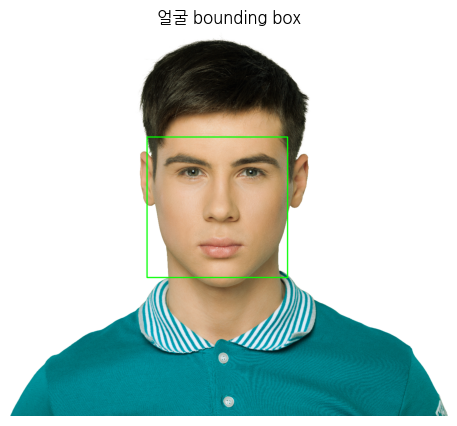

In [160]:
# [셀 목적] 사진에서 얼굴이 어디 있는지 찾아 초록 네모(bounding box)로 표시한다.
detector_hog = dlib.get_frontal_face_detector()   # 정면 얼굴 탐지기를 하나 꺼낸다 (HOG 방식)

# 사진을 넣으면 얼굴 박스들을 리스트로 돌려준다. 두번째 인자 1 = 사진을 1번 키워서도 다시 탐색
# (이 '1' 이 9-5에서 0/1/2 로 바꿔 속도를 잰 그 업샘플 횟수다. 클수록 작은 얼굴도 찾지만 느림)
dlib_rects = detector_hog(img_rgb, 1)

print('찾은 얼굴 개수:', len(dlib_rects))   # 리스트 길이 = 얼굴 수. 0이면 스티커 못 붙임

# 찾은 박스를 초록 네모로 그린다. 원본을 망치지 않게 복사본(img_show)에 그린다
img_show = img_bgr.copy()
for dlib_rect in dlib_rects:                      # 박스 하나씩 꺼내서 (얼굴 여러 명이면 여러 번)
    l, t = dlib_rect.left(), dlib_rect.top()      # 박스의 왼쪽위 모서리 (left, top)
    r, b = dlib_rect.right(), dlib_rect.bottom()  # 박스의 오른쪽아래 모서리 (right, bottom)
    # 인자: (그릴이미지, 왼위, 오른아래, 색(0,255,0)=초록(BGR), 선두께2, 선을 매끄럽게) - 11번 셀 참고
    cv2.rectangle(img_show, (l,t), (r,b), (0,255,0), 2, lineType=cv2.LINE_AA)

plt.figure(figsize=(6,5))
plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))   # 그릴 땐 다시 RGB 로
plt.title('얼굴 bounding box')
plt.axis('off')
plt.show()

> **참고 — cv2 그리기 함수 인자 읽는 법 (색 vs 크기 헷갈리지 않기)**
>
> 위 `cv2.rectangle(img_show, (l,t), (r,b), (0,255,0), 2, lineType=cv2.LINE_AA)` 한 줄에 숫자가 여러 개라 헷갈리는데, 자리마다 뜻이 정해져 있다:
>
> - `(l,t), (r,b)` : 박스의 왼쪽위·오른쪽아래 모서리 -> **박스 크기·위치를 정함** (검출된 얼굴 좌표라서, 박스 크기는 내가 정하는 게 아니라 dlib 이 잰 값)
> - `(0,255,0)` : **색상**. cv2 는 BGR 순서라 (파랑0, 초록255, 빨강0) = **초록**. (여기서 255 는 크기가 아니라 초록 채널 값이다!)
> - `2` : **선 두께**(픽셀). 박스 크기가 아니라 테두리 굵기 - 5 면 굵은 네모, 1 이면 얇은 네모.
> - `lineType=cv2.LINE_AA` : 선 가장자리를 매끄럽게(안티앨리어싱).
>
> 정리하면 한 줄 안에서 **좌표=크기·위치 / (B,G,R)=색 / 숫자 하나=선 두께** 로 역할이 갈린다.  
> 랜드마크 그릴 때 쓴 `cv2.circle(img_show, point, 2, (0,255,255), -1)` 도 같은 패턴 - `(0,255,255)` 는 색(노랑), `2` 는 점 크기(반지름), `-1` 은 속을 꽉 채우라는 뜻이다.

## 4. 랜드마크 검출 — 얼굴 안에서 코·눈·입 콕 찍기 (68개 점)

얼굴 박스만으론 코가 정확히 어디인지 모른다.  
미리 학습된 모델(`shape_predictor_68_face_landmarks.dat`)로 얼굴마다 점 68개를 찍어 코 위치(33번)를 알아낸다.  
모델 파일은 `models/` 폴더에 이미 받아 뒀다.

첫 얼굴의 랜드마크 개수: 68


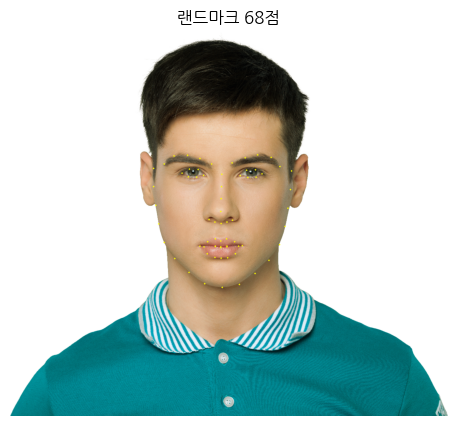

In [161]:
# [셀 목적] 얼굴 박스 안에서 눈·코·입 위치(점 68개)를 찍는다.
model_path = os.path.join(os.getcwd(), 'models', 'shape_predictor_68_face_landmarks.dat')
landmark_predictor = dlib.shape_predictor(model_path)   # 점 찍는 모델을 불러온다 (6번에서 받은 .dat)

# 얼굴 박스마다 68점을 찍어 (x,y) 목록으로 저장한다
list_landmarks = []                               # 얼굴별 점목록을 담을 빈 리스트
for dlib_rect in dlib_rects:                      # 얼굴 박스 하나씩
    points = landmark_predictor(img_rgb, dlib_rect)               # 이 얼굴의 68점 예측 (점 객체들)
    # 아래 한 줄 풀이: points.parts()=68개 점객체 / lambda p:(p.x,p.y)=점하나를 (x,y)짝으로
    #  / map(...)=그 변환을 68개에 다 적용 / list(...)=결과를 리스트로 모음 -> (x,y) 68개
    list_points = list(map(lambda p: (p.x, p.y), points.parts()))
    list_landmarks.append(list_points)            # 이 얼굴 점목록을 전체 목록에 추가

print('첫 얼굴의 랜드마크 개수:', len(list_landmarks[0]))  # 68 이 나와야 정상

# 68개 점을 노란 원으로 찍어 확인 (복사본에)
img_show = img_bgr.copy()
for landmark in list_landmarks:                   # 얼굴별 점목록
    for point in landmark:                        # 그 안의 점 하나씩 (68번 반복)
        # 인자: (그릴이미지, 점좌표, 반지름2, 색(0,255,255)=노랑(BGR), -1=속을 꽉 채움)
        cv2.circle(img_show, point, 2, (0,255,255), -1)

plt.figure(figsize=(6,5))
plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.title('랜드마크 68점')
plt.axis('off')
plt.show()

### 4b. 박스와 랜드마크를 한 그림에 같이 보기

위에서는 박스(3번)와 점(4번)을 따로 그렸다.  
사실 3번·4번 코드가 매번 `img_show = img_bgr.copy()` 로 **새 복사본**에서 시작해서, 점을 그릴 때 박스가 사라졌던 것.  
그래서 한 복사본에 박스 -> 점 순서로 차례로 그리면 얼굴 박스 + 68점을 같이 볼 수 있다.

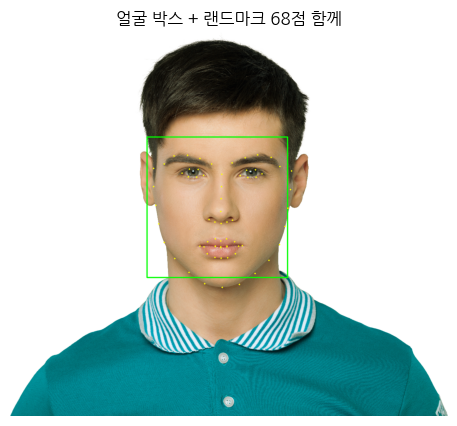

In [162]:
# [셀 목적] 박스(초록)와 68점(노랑)을 '한 그림'에 같이 그려본다.
# 원래 3번·4번은 매번 img_bgr.copy() 로 새 복사본에서 시작해 박스가 지워졌다. 여기선 한 복사본에 둘 다.
img_both = img_bgr.copy()       # 깨끗한 원본 복사본 하나에서 시작

# (1) 얼굴 박스 그리기 - 10번(섹션 3)과 똑같은 방식
for dlib_rect in dlib_rects:
    l, t = dlib_rect.left(), dlib_rect.top()        # 왼쪽위
    r, b = dlib_rect.right(), dlib_rect.bottom()    # 오른쪽아래
    cv2.rectangle(img_both, (l,t), (r,b), (0,255,0), 2, lineType=cv2.LINE_AA)   # 초록 네모

# (2) 같은 복사본 위에 랜드마크 68점 찍기 - 13번(섹션 4)과 똑같은 방식
for landmark in list_landmarks:
    for point in landmark:
        cv2.circle(img_both, point, 2, (0,255,255), -1)   # 노란 점 (속 채움)

plt.figure(figsize=(6,5))
plt.imshow(cv2.cvtColor(img_both, cv2.COLOR_BGR2RGB))
plt.title('얼굴 박스 + 랜드마크 68점 함께')
plt.axis('off')
plt.show()

## 5. 수염 올릴 위치 계산 — ★ 노드와 바꾼 곳 1 (코 33번)

수염 스티커의 **중심**을 코 밑 한가운데(33번)에 맞췄다.  
노드 왕관은 코보다 위(이마)로 끌어올렸지만, 수염은 코 자리에 둬야 하니 위로 빼지 않았다.

그 다음 중심을 스티커의 **왼쪽위 모서리**(`refined_x`, `refined_y`)로 바꿨다. 그림은 왼쪽위부터 채워지기 때문이다.

```
   refined_x          중심 x            끝
      ●─────────────────●─────────────────●
      │◄──── w//2 ────►│◄──── w//2 ────►│
      └──────────── 스티커 폭 w ──────────┘
```

In [163]:
# [셀 목적] 수염을 올릴 위치를 계산한다. 코(33번)를 중심으로 잡고 -> 스티커 왼쪽위 모서리를 구한다.
NOSE_IDX = 33   # 0~67 중 코 밑 한가운데. 노드는 30(코끝)을 썼지만 프로젝트 안내가 33을 권함

# zip(A, B) = A와 B를 짝지어 같이 돈다. 여기선 (얼굴박스, 그 얼굴의 점목록)을 한 쌍씩 꺼낸다
for dlib_rect, landmark in zip(dlib_rects, list_landmarks):
    # print(f'landmark= ({landmark})')
    x = landmark[NOSE_IDX][0]            # landmark[33] = 코점 (x,y). 그 중 [0]=가로 x
    y = landmark[NOSE_IDX][1]            # [1]=세로 y. 왕관처럼 위로 빼지 않고 코 그 자리!
    w = h = dlib_rect.width()           # 얼굴 박스 폭을 w와 h 둘 다에 넣음(정사각 스티커)
    print(f'코(33) 위치 (x,y) = ({x},{y})')
    print(f'스티커 크기 (w,h) = ({w},{h})')

# 중심(x,y) -> 스티커 왼쪽위 모서리(refined). 그림은 왼쪽위부터 채워지기 때문 (네가 잡았던 그 개념)
refined_x = x - w // 2   # 중심에서 폭 절반만큼 왼쪽으로 ( // 는 나눗셈 몫, 소수점 버림)
refined_y = y - h // 2   # 중심에서 높이 절반만큼 위로 (수염은 코 중심에 오게 절반만 뺀다)
print(f'스티커 왼쪽위 모서리 (refined_x, refined_y) = ({refined_x},{refined_y})')

코(33) 위치 (x,y) = (578,527)
스티커 크기 (w,h) = (386,386)
스티커 왼쪽위 모서리 (refined_x, refined_y) = (385,334)


## 6. 수염 스티커 불러오고 크기·경계 맞추기

수염 그림(`images/cat-whiskers.png`)을 얼굴 폭에 맞게 키운다.  
그리고 스티커 모서리가 음수(사진 경계 밖)면 그만큼 잘라낸다(개념 5).  
코에 두면 보통 위로는 안 튀어나가지만, 얼굴이 사진 가장자리에 있으면 좌우로 삐져나갈 수 있어 안전벨트로 남겨 뒀다.

In [164]:
# [셀 목적] 수염 그림을 얼굴 폭에 맞게 키우고, 사진 경계 밖으로 나간 부분은 잘라낸다.
sticker_path = os.path.join(os.getcwd(), 'images', 'cat-whiskers.png')   # 수염 그림 경로
img_sticker = cv2.imread(sticker_path)              # 읽기 (흰 배경 255 + 검은 수염 0)
img_sticker = cv2.resize(img_sticker, (w, h))       # 얼굴 폭(w,h)에 맞게 크기 조정
print('스티커 shape:', img_sticker.shape)

# 모서리(refined)가 음수면 사진 밖이다. 격자는 음수칸이 없어 -> 삐져나간 만큼 잘라야 한다
if refined_x < 0:                       # 왼쪽으로 삐져나가면 (x가 음수)
    img_sticker = img_sticker[:, -refined_x:]   # [모든행, -음수:끝] = 왼쪽 |refined_x|칸 잘라냄
    refined_x = 0                                # 시작점을 사진 왼끝(0)으로 당김
if refined_y < 0:                       # 위로 삐져나가면 (y가 음수)
    img_sticker = img_sticker[-refined_y:, :]   # [-음수:끝, 모든열] = 위쪽 |refined_y|줄 잘라냄
    refined_y = 0                                # 시작점을 사진 위끝(0)으로 당김
print(f'보정 후 모서리 (refined_x, refined_y) = ({refined_x},{refined_y})')

스티커 shape: (386, 386, 3)
보정 후 모서리 (refined_x, refined_y) = (385,334)


## 7. 합성 — ★ 노드와 바꾼 곳 2 (배경 흰색이라 `==255`)

이제 `np.where`로 수염만 코 위에 덮는다. 수염 그림은 **배경이 흰색(255), 수염이 검정(0)** 이다.  
그래서 "픽셀이 흰색(255)이면 배경이니 원본 사진을 깔고, 아니면 수염을 덮어라" 로 조건을 짰다.  
노드 왕관(배경 검정, `==0`)과 정반대다.

이건 진짜 투명이 아니라, 흰색을 초록 스크린처럼 **투명 취급**해서 그 자리에 원본을 칠하는 크로마키 방식이다.

refined_y:refined_y+img_sticker.shape[0] = (720)
refined_x:refined_x+img_sticker.shape[1] = (771)


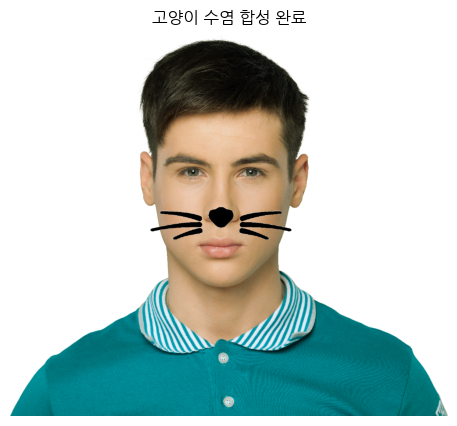

In [165]:
# [셀 목적] np.where 로 수염만 코 위에 덮는다 (배경 흰색은 원본을 살림 = 투명 취급).
# 원본에서 스티커가 올라갈 자리만 똑같은 크기로 오려둔다 (슬라이스 순서는 [세로, 가로])
sticker_area = img_bgr[refined_y:refined_y+img_sticker.shape[0],
                       refined_x:refined_x+img_sticker.shape[1]]

# 오른쪽아래 구석 = (771, 720)   <- refined + 스티커크기. shape[0]=높이(세로), shape[1]=너비(가로)
print(f'refined_y:refined_y+img_sticker.shape[0] = ({refined_y+img_sticker.shape[0]})')
print(f'refined_x:refined_x+img_sticker.shape[1] = ({refined_x+img_sticker.shape[1]})')

# np.where(조건, A, B): 픽셀마다 조건참이면 A 거짓이면 B. 흰색(255)=배경 -> 원본(area), 그외 -> 수염
# 끝의 \ 는 다음 줄까지 한 문장이라는 '줄 잇기' 기호. .astype(np.uint8)=0~255 정수형으로
img_bgr[refined_y:refined_y+img_sticker.shape[0],
        refined_x:refined_x+img_sticker.shape[1]] = \
    np.where(img_sticker == 255, sticker_area, img_sticker).astype(np.uint8)

# 완성된 합성 결과 출력
plt.figure(figsize=(6,5))
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.title('고양이 수염 합성 완료')
plt.axis('off')
plt.show()

## 8. 한 번에 돌리는 함수로 묶기

위 과정을 함수 하나(`add_cat_whiskers`)로 묶었다.  
Step 5 에서 여러 사진에 똑같이 적용하려면 함수로 만들어두는 게 깔끔하다.  
함수는 합성 결과 이미지와 **찾은 얼굴 수**를 함께 돌려준다(얼굴을 못 찾는 경우를 분석하려고).

In [166]:
# [셀 목적] 위 2~7번 과정 + (여러 명 반복) + (경계 안전장치)를 함수 하나로 묶는다.
#           이렇게 묶으면 9-1 등에서 사진마다 add_cat_whiskers(...) 한 줄로 처리할 수 있다.
def add_cat_whiskers(img_path, sticker_path, detector, predictor,   # 재료4: 사진경로,수염경로,탐지기,점모델
                     nose_idx=33, upsample=1, verbose=False):        # 기본값 있는 재료3: 코점/업샘플/말많기
    # 이미지 경로를 받아 고양이 수염을 합성한다.
    # 반환: (합성된 BGR 이미지, 찾은 얼굴 수). 얼굴 0개면 원본을 그대로 돌려준다.
    img_bgr = cv2.imread(img_path)                       # 원본 읽기 (BGR)
    if img_bgr is None:                                  # 경로가 틀리면 imread 가 None 을 준다
        raise FileNotFoundError(img_path)                # -> "파일 없음" 에러 내고 멈춤(안전장치)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)   # 검출은 RGB 로 (개념1)

    rects = detector(img_rgb, upsample)                  # 얼굴 박스들 찾기 (개념2)
    if verbose:                                          # verbose=True 면 찾은 수 출력(디버깅용)
        print(f'  찾은 얼굴 수: {len(rects)}')
    if len(rects) == 0:                                  # 얼굴 0개면 더 할 게 없음
        return img_bgr, 0                                # -> 원본 그대로 + 0 주고 함수 끝(return)

    sticker_raw = cv2.imread(sticker_path)               # 수염 스티커 (흰 배경+검은 수염)

    for rect in rects:                                   # 얼굴마다 반복 (여러 명이면 여러 번)
        points = predictor(img_rgb, rect)                # 이 얼굴의 68점 예측
        landmark = list(map(lambda p: (p.x, p.y), points.parts()))   # 점들을 (x,y) 68개 목록으로(개념3)

        x = landmark[nose_idx][0]                        # 코점(33)의 가로 x
        y = landmark[nose_idx][1]                        # 코점의 세로 y (위로 안 뺌)
        w = h = rect.width()                             # 얼굴 폭을 w,h 둘 다에 (정사각)

        sticker = cv2.resize(sticker_raw, (w, h))        # 수염을 얼굴 폭에 맞게 키움
        rx, ry = x - w // 2, y - h // 2                  # 중심 -> 왼쪽위 모서리(개념4)

        if rx < 0:                                       # 왼쪽 밖이면 잘라내고 0으로 (개념5)
            sticker = sticker[:, -rx:]; rx = 0           # ; 은 한 줄에 명령 두 개
        if ry < 0:                                       # 위쪽 밖이면 잘라내고 0으로
            sticker = sticker[-ry:, :]; ry = 0
        # 오른쪽/아래로 넘치는 경우도 잘라준다 (얼굴이 사진 가장자리일 때 에러 방지 - 개념5의 추가 안전장치)
        sh, sw = sticker.shape[:2]                       # 현재 수염의 (높이, 너비)
        sh = min(sh, img_bgr.shape[0] - ry)              # 사진에 남은 세로 공간보다 크면 그만큼 줄임
        sw = min(sw, img_bgr.shape[1] - rx)              # 사진에 남은 가로 공간보다 크면 그만큼 줄임
        sticker = sticker[:sh, :sw]                      # 줄인 크기로 다시 자름

        area = img_bgr[ry:ry+sh, rx:rx+sw]               # 붙일 자리 원본을 같은 크기로 오림(개념6)
        img_bgr[ry:ry+sh, rx:rx+sw] = \
            np.where(sticker == 255, area, sticker).astype(np.uint8)  # 흰배경=투명취급(개념6)

    return img_bgr, len(rects)                           # 합성된 사진 + 얼굴 수를 돌려줌


def show_bgr(img_bgr, title=''):                         # BGR->RGB 바꿔 그려주는 출력 도우미
    # BGR 이미지를 RGB 로 바꿔 출력하는 헬퍼
    plt.figure(figsize=(5,5))
    plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    plt.title(title); plt.axis('off'); plt.show()

print('함수 준비 완료')

함수 준비 완료


  찾은 얼굴 수: 1


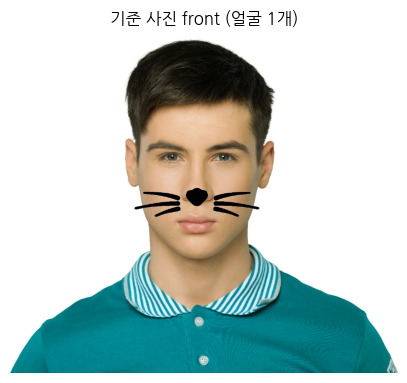

In [167]:
# [셀 목적] 위에서 만든 함수가 잘 도는지 기준 사진(front)으로 한 번 더 확인한다.
base_path = os.path.join(os.getcwd(), 'images', 'front.png')          # 기준 사진 경로 (뒤 실험들도 이걸 씀)
sticker_path = os.path.join(os.getcwd(), 'images', 'cat-whiskers.png') # 수염 경로

# 함수는 (합성된 이미지, 얼굴 수) 두 값을 돌려준다 -> result, n 에 한 번에 받는다
result, n = add_cat_whiskers(base_path, sticker_path,
                             detector_hog, landmark_predictor, verbose=True)
show_bgr(result, f'기준 사진 front (얼굴 {n}개)')   # 결과를 제목과 함께 출력

## 9. Step 5 — 문제점 찾아보기

이 스티커앱을 여러 상황(각도·밝기·거리 다르게)에 적용해 보면서, **언제 잘 되고 언제 틀리는지**를 정리해본다.

- 얼굴 각도에 따라 스티커가 어떻게 변해야 할까?
- 멀리서 촬영하면 왜 안 될까? 옆으로 누워서 촬영하면 왜 안 될까?
- 실행 속도가 중요할까?
- 스티커앱을 만들 때 정확도는 얼마나 중요할까?

사진준비:  
(1) 캔바에서 받은 다양한 실제 사진과  
(2) 기준 사진을 코드로 변형(밝기·거리·각도)한 것을 둘 다 써서 실험했다.  
사진은 라이선스 문제 없는 캔바 프로 이미지라 동일 인물이 아니어도 된다(각 사진은 독립적으로 얼굴을 찾아 분석하니까).

### 9-1. 다양한 실제 사진 (정면 / 아이 / 옆얼굴 / 기울임 / 여러 명)

캔바 프로(라이선스 OK)에서 받은 실제 인물 사진 5장에 앱을 적용해 봤다.  
동일 인물이 아니어도 되고(각 사진을 독립적으로 처리), 각각 다른 변수를 노린다.  
검출이 **될지 안 될지**를 미리 예상하고 돌려 확인했다:

- `front` : 깨끗한 정면(성인) — 잘 되는 기준 (예상: 성공)
- `child` : 정면(아이) — 얼굴 종류가 달라도 되는지 (예상: 성공)
- `side`  : 완전 옆얼굴(프로필) — 정면 탐지기가 얼굴로 못 알아봄 (예상: 검출 실패, 수염 안 붙음)
- `tilt`  : 고개를 기울이고 손으로 얼굴 일부를 가린 사진 — 각도 + 가림이 겹친 경우 (예상: 검출 실패)
- `group` : 여러 명이 함께 — for문이 박스 여러 개를 도는지 (예상: 얼굴 여러 개 검출, 전원에 수염)


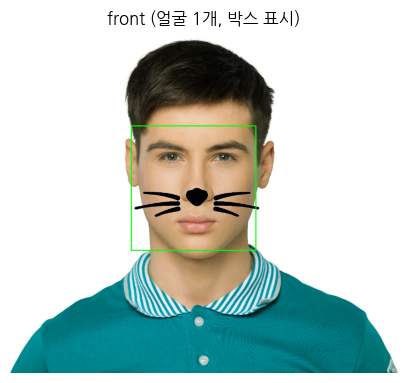

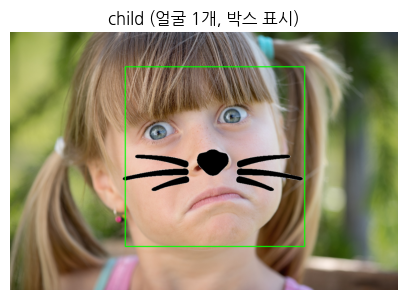

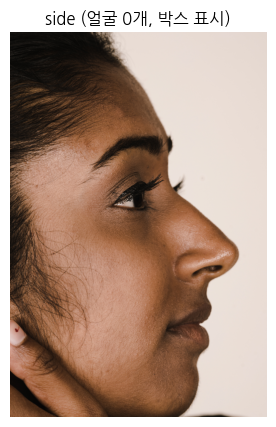

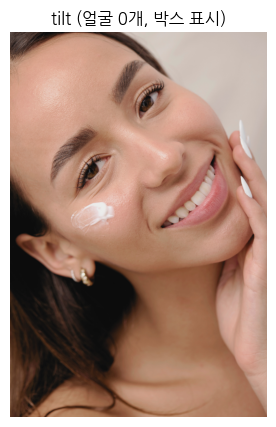

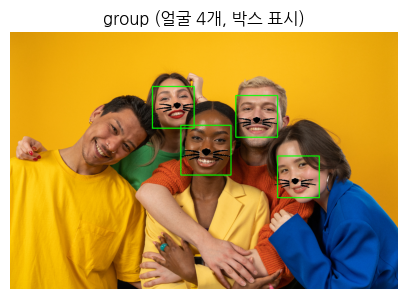

실제 사진별 검출된 얼굴 수: {'front': 1, 'child': 1, 'side': 0, 'tilt': 0, 'group': 4}


In [168]:
# [셀 목적] 캔바 실제 사진 여러 장에 앱을 한꺼번에 적용한다(있는 파일만 자동으로).
test_names = ['front', 'child', 'side', 'tilt', 'group']   # 분석할 사진 이름들
img_dir = os.path.join(os.getcwd(), 'images')

def find_file(stem):                          # 이름(stem)에 맞는 파일을 확장자 바꿔가며 찾는다
    for ext in ('.png', '.jpg', '.jpeg', '.webp'):   # png/jpg 등 후보를 차례로
        p = os.path.join(img_dir, stem + ext)
        if os.path.exists(p):                 # 그 파일이 실제로 있으면
            return p                          # 그 경로를 돌려주고 끝
    return None                               # 다 없으면 None

results_real = {}   # 사진이름 -> 얼굴수 를 표로 모으려고 저장 (딕셔너리)
for name in test_names:
    path = find_file(name)
    if path is None:                          # 파일이 아직 없으면
        print(f'[건너뜀] {name} : images/ 에 파일이 아직 없음')
        continue                              # 이 사진은 건너뛰고 다음으로
    res, n = add_cat_whiskers(path, sticker_path,
                              detector_hog, landmark_predictor, verbose=False)
    
    # 검출된 얼굴 위치에 초록 박스도 같이 표시 (원본에서 다시 검출해 좌표를 얻는다)
    orig_rgb = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    for rect in detector_hog(orig_rgb, 1):    # 찾은 얼굴마다
        cv2.rectangle(res, (rect.left(), rect.top()), (rect.right(), rect.bottom()),
                      (0, 255, 0), 2, lineType=cv2.LINE_AA)   # 합성 결과에 초록 박스
    results_real[name] = n                    # 이 사진의 얼굴 수 기록
    show_bgr(res, f'{name} (얼굴 {n}개, 박스 표시)')

print('실제 사진별 검출된 얼굴 수:', results_real)   # side·tilt 는 0 (다음 셀에서 왜인지 분석)

### 9-1 들여다보기 — side·tilt 는 왜 검출이 안 됐나

갤러리에서 side(옆얼굴)와 tilt(고개 기울임+손)가 얼굴 0개로 수염이 안 붙었다.  
처음엔 "얼굴이 프레임에 꽉 차서 여백이 없어 그런가?" 싶었는데, **직접 테스트해보니 아니었다.**

- **"프레임에 꽉 차서"가 아니다**: 두 사진 사방에 흰 여백을 400px 씩 크게 덧대고(`cv2.copyMakeBorder`) 다시 검출해도 여전히 0개였다.  
  여백 부족이 원인이면 여백을 주면 잡혀야 하는데 안 잡혔다. (업샘플 up2·up3 로 키워도 0개.)
- **side = 완전 옆얼굴(프로필)**: 눈이 한쪽만 보이고 코가 옆 실루엣이라, "두 눈이 좌우로 보이는 정면"을 찾도록 학습된 정면 탐지기가 얼굴로 못 알아본다.
- **tilt = 고개 기울기(roll)**: 이미지를 -5 ~ -30도로 돌려 머리를 똑바로 세우면 **검출이 된다.**  
  즉 고개가 정면 탐지기가 견디는 각도를 넘어 기울어 있던 게 원인이다.

정리하면 둘의 공통점은 "프레임이 꽉 차서"가 아니라 **정면 직립 얼굴이 아니라서**다(옆을 보거나, 고개가 기울거나). 이건 9-4 회전 실험에서 45도까지는 잡히고 60도부터 실패했던 것과 같은 맥락이다.

> 참고로 이건 보너스 11번(수염 회전)의 한계도 보여준다 - 11번은 *검출된* 기운 얼굴에 수염을 같이 기울이는 거라, tilt 처럼 *검출 자체가 안 되는* 경우엔 적용할 수조차 없다.  
> 이런 얼굴까지 잡으려면 이미지를 여러 각도로 돌려가며 검출을 시도하는 별도 기법이 필요하다.

side.png : 원본 0개 | 사방 여백400px 0개 | 업샘플2 0개
tilt.png : 원본 0개 | 사방 여백400px 0개 | 업샘플2 0개
-> 여백을 줘도 0개. "프레임에 꽉 차서"가 원인이 아니다.

tilt.png 을 돌려서 검출에 성공한 각도: [-30, -25, -20, -15, -10, -5] (도)
-> 원본(0도)은 실패하지만 -5~-30도로 머리를 펴면 검출됨 = 고개 기울기가 원인.


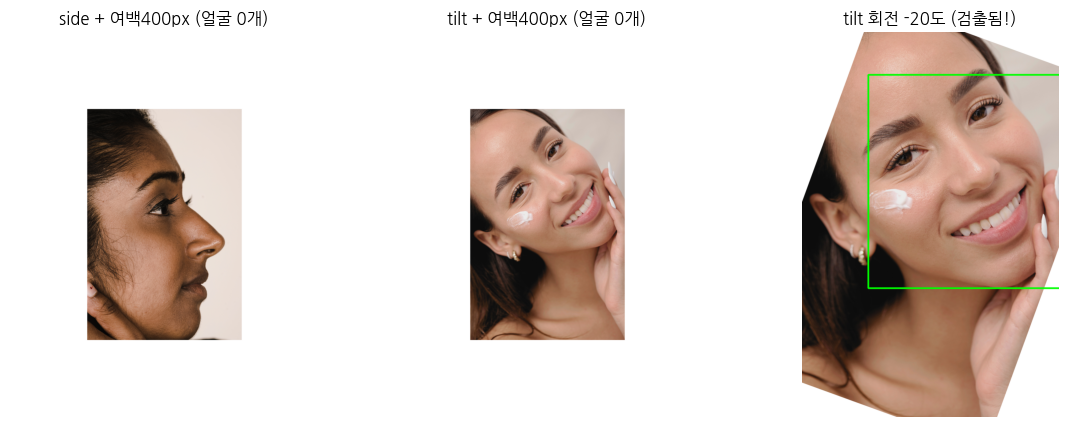

In [169]:
# 위 분석을 추측이 아니라 코드로 직접 확인한다 (내 가설을 코드로 직접 확인).

# [테스트1] 가설 '프레임에 꽉 차서' -> 사방에 흰 여백 400px 를 덧대고(cv2.copyMakeBorder) 재검출.
#           여백 부족이 원인이면 여백을 주면 잡혀야 한다.
for name in ['side', 'tilt']:
    img = cv2.imread(os.path.join(os.getcwd(), 'images', name + '.png'))
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    base_n = len(detector_hog(rgb, 1))                          # 원본 검출 수
    # copyMakeBorder(이미지, 위,아래,왼,오 각 400px, 단색테두리, value=흰색) = 사방에 흰 여백 추가
    padded = cv2.copyMakeBorder(img, 400, 400, 400, 400,
                                cv2.BORDER_CONSTANT, value=(255, 255, 255))
    pad_n = len(detector_hog(cv2.cvtColor(padded, cv2.COLOR_BGR2RGB), 1))  # 여백 추가 후 검출 수
    up2_n = len(detector_hog(rgb, 2))                           # 업샘플 2로 키워도 (작은얼굴 더 탐색)
    print(f'{name}.png : 원본 {base_n}개 | 사방 여백400px {pad_n}개 | 업샘플2 {up2_n}개')
print('-> 여백을 줘도 0개. "프레임에 꽉 차서"가 원인이 아니다.')
print()

# [테스트2] tilt 는 고개 기울기가 원인인가? -> 이미지를 여러 각도로 돌려(머리를 세워) 검출되는 각도를 찾는다.
def _rotate(img, angle):                       # 이미지를 angle 도 회전 (빈 곳은 흰색)
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)   # 회전 변환표(중심,각도,배율1)를 만들고
    return cv2.warpAffine(img, M, (w, h), borderValue=(255, 255, 255))   # 그 표대로 이미지를 돌림

tilt_img = cv2.imread(os.path.join(os.getcwd(), 'images', 'tilt.png'))
detected_angles = []                           # 검출 성공한 각도를 모을 리스트
for a in range(-30, 31, 5):                    # -30도 ~ +30도, 5도 간격
    n = len(detector_hog(cv2.cvtColor(_rotate(tilt_img, a), cv2.COLOR_BGR2RGB), 1))
    if n > 0:                                  # 그 각도에서 얼굴이 잡혔다면
        detected_angles.append(a)              # 그 각도를 기록
print(f'tilt.png 을 돌려서 검출에 성공한 각도: {detected_angles} (도)')
print('-> 원본(0도)은 실패하지만 -5~-30도로 머리를 펴면 검출됨 = 고개 기울기가 원인.')

# 위 테스트를 눈으로도 확인한다. 박스는 '검출된 얼굴'에만 그려지므로,
# 여백 준 사진엔 박스가 없고(검출 0), 회전해 머리를 세운 tilt 엔 박스가 생긴다.
def _draw_boxes(img):                          # 검출된 얼굴마다 초록 박스를 그려 돌려주는 도우미
    out = img.copy()
    for r in detector_hog(cv2.cvtColor(out, cv2.COLOR_BGR2RGB), 1):
        cv2.rectangle(out, (r.left(), r.top()), (r.right(), r.bottom()),
                      (0, 255, 0), 3, lineType=cv2.LINE_AA)
    return out

side_pad = cv2.copyMakeBorder(cv2.imread(os.path.join(os.getcwd(), 'images', 'side.png')),
                              400, 400, 400, 400, cv2.BORDER_CONSTANT, value=(255, 255, 255))
tilt_pad = cv2.copyMakeBorder(tilt_img, 400, 400, 400, 400, cv2.BORDER_CONSTANT, value=(255, 255, 255))
panels = [                                     # (보여줄 이미지, 제목) 3장 묶음
    (_draw_boxes(side_pad),               'side + 여백400px (얼굴 0개)'),
    (_draw_boxes(tilt_pad),               'tilt + 여백400px (얼굴 0개)'),
    (_draw_boxes(_rotate(tilt_img, -20)), 'tilt 회전 -20도 (검출됨!)'),
]
fig, axes = plt.subplots(1, 3, figsize=(14, 5))   # 그림 1행 3칸으로 나란히
for ax, (im, t) in zip(axes, panels):             # 칸(ax)과 (이미지,제목)을 짝지어
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB)); ax.set_title(t); ax.axis('off')
plt.show()

### 9-2. 밝기 변수 (코드로 기준 사진을 어둡게/밝게)

기준 사진의 픽셀값에 배수를 곱해 밝기를 바꾼 뒤, 얼굴이 검출되는지 봤다.  
변수 하나(밝기)만 바꿔 영향을 따로 떼어 보려고 코드로 만들었다.  
일반 범위뿐 아니라 극단(아주 어둡게 0.05배 ~ 과노출 5.0배)까지 넣어 **어디서 깨지는지** 한계점을 찾아본다.

밝기 배수별 검출된 얼굴 수: {0.05: 0, 0.1: 1, 0.2: 1, 1.0: 1, 2.2: 1, 5.0: 0}


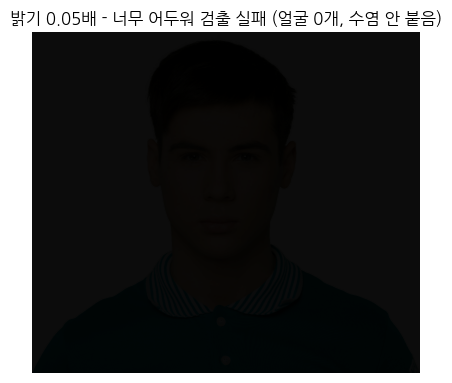

In [170]:
# [셀 목적] 밝기를 바꿔가며 검출이 언제 깨지는지 본다 (변수=밝기 하나만 통제).
# change_brightness: 픽셀값 * 배수. 배수<1 이면 어둡게, >1 이면 밝게.
def change_brightness(img_bgr, factor):
    # astype(float32)=곱셈 위해 실수로 / *factor=밝기조절 / np.clip(...,0,255)=범위 넘으면 자름 / uint8=다시 정수
    return np.clip(img_bgr.astype(np.float32) * factor, 0, 255).astype(np.uint8)

base_bgr = cv2.imread(base_path)               # 기준 사진(front) 한 장
brightness_factors = [0.05, 0.1, 0.2, 1.0, 2.2, 5.0]   # 극단 어둠 ~ 과노출
bright_faces = {}                              # 배수 -> 얼굴수 기록할 딕셔너리
for f in brightness_factors:
    dimmed = change_brightness(base_bgr, f)    # 그 배수로 밝기 바꾼 사진
    rgb = cv2.cvtColor(dimmed, cv2.COLOR_BGR2RGB)
    n = len(detector_hog(rgb, 1))              # 그 밝기에서 얼굴이 잡히나
    bright_faces[f] = n                        # 결과 기록

print('밝기 배수별 검출된 얼굴 수:', bright_faces)
# 결과(front.png): 0.1~3.0 범위는 다 검출됨. 0.05 이하(극단 어둠)나 5.0(과노출)에서만 0개로 실패.
# HOG 는 밝기 자체가 아니라 픽셀 '기울기(gradient)'를 보기 때문에 균일한 밝기 변화엔 꽤 강하다.

# 눈으로 확인: 검출이 실패하는 0.05배(거의 깜깜)에 합성 시도하면 수염이 안 붙는다(얼굴 0개)
dimmed = change_brightness(base_bgr, 0.05)
tmp = os.path.join(os.getcwd(), 'images', '_tmp_dark.png')   # add_cat_whiskers 는 경로를 받으니 임시저장
cv2.imwrite(tmp, dimmed)
res, n = add_cat_whiskers(tmp, sticker_path, detector_hog, landmark_predictor)
show_bgr(res, f'밝기 0.05배 - 너무 어두워 검출 실패 (얼굴 {n}개, 수염 안 붙음)')
os.remove(tmp)                                 # 임시파일은 쓰고 바로 지운다

### 9-3. 거리(크기) 변수 (코드로 기준 사진을 축소)

멀리서 찍으면 얼굴이 작게 나온다.  
기준 사진을 여러 배율로 줄여서, 얼굴이 너무 작아지면 검출이 실패하는지 확인한다.  
한계점을 찾으려고 가로 픽셀 수도 같이 출력했다.

In [171]:
# [셀 목적] 사진을 점점 줄여(멀리서 찍은 효과) 얼굴이 얼마나 작아지면 검출이 깨지는지 본다.
scales = [1.0, 0.3, 0.15, 0.1, 0.08, 0.05]     # 1배(원본) ~ 0.05배(아주 작게)
dist_faces = {}                                # 배율 -> (얼굴수, 가로px) 기록
for s in scales:
    small = cv2.resize(base_bgr, None, fx=s, fy=s)   # 가로·세로를 s배로 축소 (fx,fy=배율)
    rgb = cv2.cvtColor(small, cv2.COLOR_BGR2RGB)
    n = len(detector_hog(rgb, 1))
    dist_faces[s] = (n, small.shape[1])   # (얼굴 수, 그때 사진 가로 픽셀) - 한 칸에 두 값을 튜플로
print('축소 배율별 (얼굴 수, 사진 가로px):', dist_faces)
# 결과(front.png): 사진 가로 96px(0.08배)까지는 검출, 60px(0.05배)부터 0개로 실패.
# 즉 얼굴이 일정 픽셀 크기보다 작아지면 탐지기가 못 잡는다. detector(img, 2)처럼
# 업샘플을 키우면 작은 얼굴도 더 잡지만 그만큼 느려진다(속도-정확도 맞바꿈, 아래 Q3).

축소 배율별 (얼굴 수, 사진 가로px): {1.0: (1, 1200), 0.3: (1, 360), 0.15: (1, 180), 0.1: (1, 120), 0.08: (1, 96), 0.05: (0, 60)}


위 숫자를 눈으로도 확인해 봤다.  
배율별로 줄인 사진에 수염을 붙여, **원본 크기 흰 캔버스 위에 얹어** 나란히 놓으면 멀어질수록(배율이 작을수록) 얼굴이 점점 작아지는 게 보인다.  
검출은 9-3과 똑같이 줄인 이미지에서 하니 얼굴 수도 위 dict 와 일치한다 - 너무 작아지는 0.05배에서 얼굴 0개라 수염도 안 붙는다.

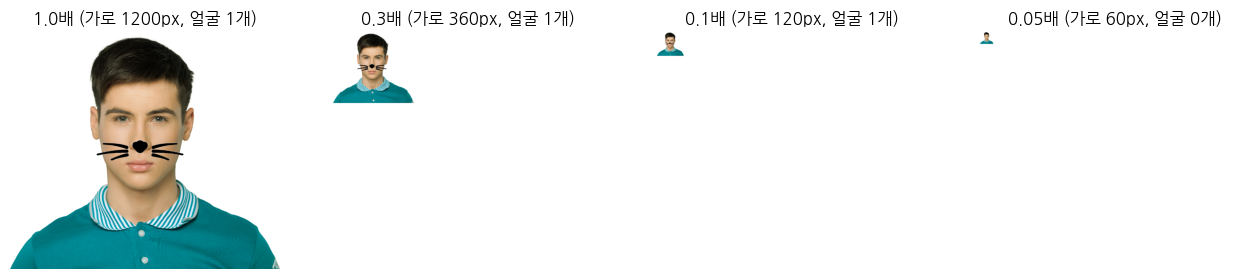

In [172]:
# [셀 목적] 위 9-3 숫자를 눈으로. 배율별로 줄인 사진을 원본 크기 흰 캔버스에 얹어 '멀어짐'을 보인다.
show_scales = [1.0, 0.3, 0.1, 0.05]
H, W = base_bgr.shape[:2]                      # 원본(기준) 세로H·가로W = 캔버스 크기
fig, axes = plt.subplots(1, len(show_scales), figsize=(4*len(show_scales), 4))   # 1행 4칸

for ax, s in zip(axes, show_scales):           # 칸(ax)과 배율(s)을 짝지어
    small = cv2.resize(base_bgr, None, fx=s, fy=s)        # s배로 축소(멀어지는 효과)
    tmp = os.path.join(os.getcwd(), 'images', '_tmp_scale.png')   # 함수가 경로를 받으니 임시저장
    cv2.imwrite(tmp, small)
    composed, n = add_cat_whiskers(tmp, sticker_path, detector_hog, landmark_predictor)
    os.remove(tmp)
    canvas = np.full((H, W, 3), 255, np.uint8)            # np.full=온통 255(흰색)인 원본 크기 판
    sh, sw = composed.shape[:2]                           # 줄인 결과의 (높이, 너비)
    canvas[:sh, :sw] = composed                           # 그 판의 왼쪽위에 줄인 결과를 얹는다
    ax.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
    ax.set_title(f'{s}배 (가로 {sw}px, 얼굴 {n}개)')
    ax.axis('off')
plt.show()

### 9-3b. 진짜 멀리서 찍은 사진으로 확인

위 9-3은 코드로 사진을 줄여서 거리를 흉내 냈는데, 사실 "멀리서"라는 말 자체가 좀 주관적이다  
  - 아무리 멀어도 **얼굴이 화면에 어느 정도는 보여야** 검출이라도 시도하지, 점처럼 작아지면 얼굴인지조차 알 수 없다.

그래서 실제로 사람이 멀리 앉아 작게 나온 사진(`far.png`)에 앱을 적용해 봤다.  
결과를 보면 얼굴이 작아도 **검출은 되고 수염도 붙긴 하는데 아주 작게** 붙는다.  
얼굴 박스 크기를 같이 출력해서 정면 기준 사진(front, 약 386px)과 비교했다.  
여기서 더 멀어져 얼굴이 9-3에서 본 한계(대략 가로 40~60px) 아래로 작아지면, 그땐 검출 자체가 안 돼서 수염도 못 붙는다.

far.png 얼굴 박스 폭: 44px  (정면 front 는 약 386px)
  찾은 얼굴 수: 1


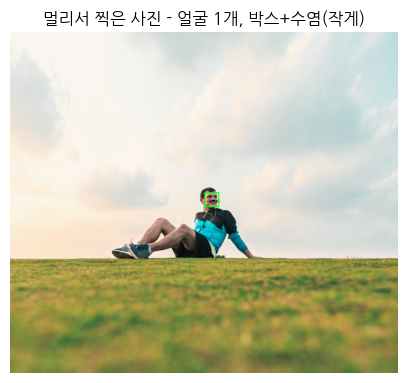

In [173]:
# [셀 목적] 실제 멀리서 찍어 얼굴이 작게 나온 사진(far.png). 검출되는지 + 수염이 얼마나 작은지.
far_path = os.path.join(os.getcwd(), 'images', 'far.png')

# 얼굴 박스 크기를 정면 기준과 비교한다 (멀수록 박스가 작아짐)
far_bgr = cv2.imread(far_path)
far_rgb = cv2.cvtColor(far_bgr, cv2.COLOR_BGR2RGB)
far_rects = detector_hog(far_rgb, 1)                    # 이 사진의 얼굴 박스들
if far_rects:                                           # 하나라도 찾았으면 (빈 리스트면 False)
    print(f'far.png 얼굴 박스 폭: {far_rects[0].width()}px  (정면 front 는 약 386px)')

# 같은 함수로 수염 합성 (멀어서 박스가 작으니 수염도 작게 붙는다)
far_result, far_n = add_cat_whiskers(far_path, sticker_path,
                                     detector_hog, landmark_predictor, verbose=True)
# 검출된 얼굴 박스도 같이 표시 (위에서 구한 far_rects 사용)
for rect in far_rects:
    cv2.rectangle(far_result, (rect.left(), rect.top()), (rect.right(), rect.bottom()),
                  (0, 255, 0), 2, lineType=cv2.LINE_AA)
show_bgr(far_result, f'멀리서 찍은 사진 - 얼굴 {far_n}개, 박스+수염(작게)')

### 9-3c. 대비 변수 (추가 발견 — 밝기보다 대비가 더 직접적)

밝기 실험에서 "HOG 는 픽셀 기울기를 본다"는 걸 알았으니,  
밝기 말고 **대비(contrast)** 를 직접 죽이면 어떻게 되는지 확인했다.  
대비를 낮추면 픽셀들이 평균값 쪽으로 뭉쳐 기울기가 사라진다.

대비 배수별 검출된 얼굴 수: {1.0: 1, 0.3: 1, 0.15: 1, 0.08: 1, 0.05: 1, 0.03: 0}


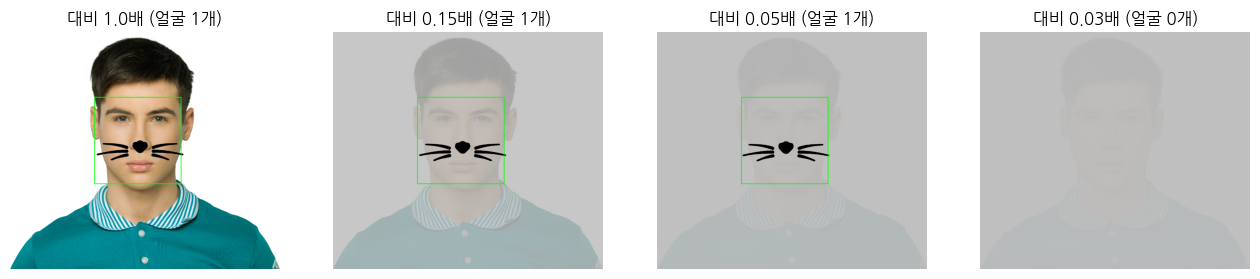

In [174]:
# [셀 목적] 대비(명암 차이)를 낮춰가며 검출이 언제 깨지는지 본다.
# change_contrast: 각 픽셀을 '평균값 쪽으로' k배 끌어모은다. k<1 이면 명암 차이가 줄어 밋밋해짐.
def change_contrast(img_bgr, k):
    m = img_bgr.mean()                                  # 사진 전체 픽셀의 평균 밝기
    # (픽셀-평균)=평균에서 얼마나 떨어졌나, *k=그 차이를 k배로 줄임, +평균=다시 제자리로, clip/uint8=정리
    return np.clip((img_bgr.astype(np.float32) - m) * k + m, 0, 255).astype(np.uint8)

contrast_ks = [1.0, 0.3, 0.15, 0.08, 0.05, 0.03]        # 1.0=원본 ~ 0.03=거의 평평
contrast_faces = {}
for k in contrast_ks:
    flat = change_contrast(base_bgr, k)                 # 대비 낮춘 사진
    n = len(detector_hog(cv2.cvtColor(flat, cv2.COLOR_BGR2RGB), 1))
    contrast_faces[k] = n

print('대비 배수별 검출된 얼굴 수:', contrast_faces)
# 결과(front.png): 0.03배로 거의 완전히 평평해져야 0개로 실패. 대비엔 꽤 강건한 편이지만,
# 명암 차이(기울기)가 거의 사라지면 결국 검출이 무너진다 - HOG 가 기울기를 보기 때문.

# 대비 단계별로 이미지도 같이 본다 (수염 + 박스). 0.03배엔 검출 실패라 박스·수염이 안 나온다.
show_ks = [1.0, 0.15, 0.05, 0.03]
fig, axes = plt.subplots(1, len(show_ks), figsize=(4*len(show_ks), 4))   # 1행 4칸

for ax, k in zip(axes, show_ks):
    flat = change_contrast(base_bgr, k)
    tmp = os.path.join(os.getcwd(), 'images', '_tmp_contrast.png')        # 함수가 경로를 받으니 임시저장
    cv2.imwrite(tmp, flat)
    comp, n = add_cat_whiskers(tmp, sticker_path, detector_hog, landmark_predictor)
    os.remove(tmp)
    for rect in detector_hog(cv2.cvtColor(flat, cv2.COLOR_BGR2RGB), 1):   # 박스도 함께
        cv2.rectangle(comp, (rect.left(), rect.top()), (rect.right(), rect.bottom()),
                      (0, 255, 0), 2, lineType=cv2.LINE_AA)
    ax.imshow(cv2.cvtColor(comp, cv2.COLOR_BGR2RGB))
    ax.set_title(f'대비 {k}배 (얼굴 {n}개)')
    ax.axis('off')
plt.show()

### 9-4. 각도(회전) 변수 (코드로 기준 사진을 기울임)

고개를 갸웃하면(이미지 평면 회전) 두 가지 문제가 생긴다 — 큰 각도에선 정면 탐지기가 얼굴을 놓치고, 검출이 되더라도 수염은 안 기울어 얼굴과 따로 논다.  
기준 사진을 여러 각도로 돌려서 확인해본다.

회전 각도별 검출된 얼굴 수: {0: 1, 15: 1, 30: 1, 45: 1, 60: 0, 90: 0}


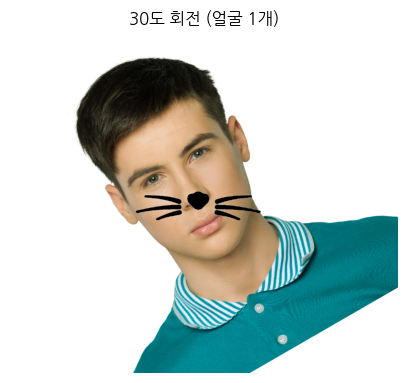

In [175]:
# [셀 목적] 고개를 기울인(이미지 회전) 얼굴이 몇 도까지 검출되는지 본다.
def rotate_image(img_bgr, angle):              # 이미지를 중심 기준 angle 도 회전
    h, w = img_bgr.shape[:2]                   # 세로 h, 가로 w
    M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)   # 회전 변환표(중심, 각도, 배율1)
    return cv2.warpAffine(img_bgr, M, (w, h), borderValue=(255,255,255))   # 그 표대로 돌림(빈곳 흰색)

angles = [0, 15, 30, 45, 60, 90]               # 0도(똑바로) ~ 90도(완전 옆)
rot_faces = {}                                 # 각도 -> 얼굴수 기록
for a in angles:
    rotated = rotate_image(base_bgr, a)        # a도 회전한 사진
    rgb = cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB)
    n = len(detector_hog(rgb, 1))
    rot_faces[a] = n

print('회전 각도별 검출된 얼굴 수:', rot_faces)
# 결과(front.png): 45도까지는 검출되지만 60도부터 0개로 실패. 30도 합성을 보면 얼굴은
# 기울었는데 수염은 똑바로라 따로 논다(아래). 큰 각도에선 검출 자체가 안 된다.

# 30도 회전에 합성 시도 (수염이 안 기울어 따로 노는 걸 눈으로 확인)
rotated = rotate_image(base_bgr, 30)
tmp = os.path.join(os.getcwd(), 'images', '_tmp_rot.png')   # 함수가 경로를 받으니 임시저장
cv2.imwrite(tmp, rotated)
res, n = add_cat_whiskers(tmp, sticker_path, detector_hog, landmark_predictor)
show_bgr(res, f'30도 회전 (얼굴 {n}개)')
os.remove(tmp)

### 9-5. 실행 속도 변수 (실제로 시간 재보기)

Step 5 의 "실행 속도가 중요할까?"에 대해 실제로 시간을 재봤다.  
카메라앱은 보통 실시간(영상)으로 매 프레임을 처리해야 해서, 한 장 처리에 얼마나 걸리는지가 중요할 것이다.  
세 가지를 측정했다:  
(1) 작은 얼굴을 더 찾으려고 업샘플을 키울 때 얼마나 느려지나,  
(2) 검출과 랜드마크 중 어디서 시간이 드나,  
(3) 이미지 크기를 줄이면(resize) 얼마나 빨라지나.  
(절대 ms 값은 컴퓨터마다 다르니, 셋 사이의 '배수 차이'를 보면 될것 같다.)

In [176]:
# ──────────────────────────────────────────────────────────────────────
# [무슨 이미지로?] 새 이미지를 고른 게 아니다. 계속 쓰던 기준 사진(front.png)을 그대로 쓴다.
#   speed_img = front.png  (base_path 는 앞 8번에서 images/front.png 로 정해둔 변수)
#
# [업샘플이 뭐고 어디서 키우나?] 따로 사진을 키우는 코드(cv2.resize 등)가 없다 -
#   3번 얼굴검출에서 본 detector_hog(img, 1) 의 그 '두번째 숫자'가 바로 업샘플 횟수다.
#   그 숫자(u)만큼 dlib 이 내부에서 사진을 키워(image pyramid) 검출한다. 우리는 횟수만 넘긴다.
#   u=0 안 키움(빠름·작은 얼굴 놓침) / u=1 보통 / u=2 두 번 키움(느림·작은 얼굴도 잡음)
#   (참고: dlib 공식 예제 face_detector.py 도 detector(img, 1) 로 1번 업샘플한다.)
# ──────────────────────────────────────────────────────────────────────
import time

def measure_ms(fn, rep=3):
    # fn 이라는 '작업 하나'를 rep 번 돌려서 1회당 평균 시간(ms)을 재주는 초시계.
    fn()                                  # 워밍업 (첫 호출은 느릴 수 있어 측정에서 뺀다)
    t = time.perf_counter()               # 시작 시각
    for _ in range(rep):
        fn()                              # 같은 작업을 rep 번 반복
    return (time.perf_counter() - t) / rep * 1000   # (총 걸린 시간 / 횟수) -> 1회당 ms

speed_img = cv2.imread(base_path)                    # base_path = images/front.png (기준 사진 그대로)
speed_rgb = cv2.cvtColor(speed_img, cv2.COLOR_BGR2RGB)

# (1) 업샘플(작은 얼굴을 더 찾기)을 키울수록 느려진다 - 속도 vs 정확도 맞바꿈
#     lambda: detector_hog(speed_rgb, u) = '잴 대상'을 지금 실행하지 않고 포장해서
#     measure_ms 에 넘긴다(거기서 여러 번 실행하며 시간을 잰다).
print('[업샘플별 검출 시간]  (같은 front.png 를 0/1/2 번 키워가며 검출)')
for u in [0, 1, 2]:
    ms = measure_ms(lambda: detector_hog(speed_rgb, u))   # u번 업샘플 검출에 걸리는 시간
    n = len(detector_hog(speed_rgb, u))                   # 그때 찾은 얼굴 수
    print(f'  업샘플 {u}: {ms:7.1f} ms  (얼굴 {n}개)')

# (2) 단계별 시간 - 검출과 랜드마크 중 어디서 시간이 드나
rects = detector_hog(speed_rgb, 1)
t_det = measure_ms(lambda: detector_hog(speed_rgb, 1))            # 얼굴 검출 한 번
t_lm  = measure_ms(lambda: landmark_predictor(speed_rgb, rects[0]))  # 한 얼굴 랜드마크 한 번
print(f'\n[단계별] 얼굴 검출: {t_det:.1f} ms   vs   랜드마크 68점(1얼굴): {t_lm:.2f} ms')
print(f'  -> 검출이 랜드마크보다 더 오래 걸린다 = 병목은 검출 단계')

# (3) 이미지 크기(해상도)를 줄이면 빨라진다 (이건 우리가 직접 cv2.resize 로 줄인다)
print('\n[이미지 크기별 검출 시간]')
for s in [1.0, 0.5]:
    small = cv2.resize(speed_img, None, fx=s, fy=s)
    srgb = cv2.cvtColor(small, cv2.COLOR_BGR2RGB)
    ms = measure_ms(lambda: detector_hog(srgb, 1))
    print(f'  {s}배 (가로 {small.shape[1]}px): {ms:.1f} ms')
print('  -> 해상도를 줄이면 검출이 크게 빨라진다(대신 작은 얼굴은 놓칠 수 있다)')

[업샘플별 검출 시간]  (같은 front.png 를 0/1/2 번 키워가며 검출)


  업샘플 0:   102.5 ms  (얼굴 1개)
  업샘플 1:   432.0 ms  (얼굴 1개)
  업샘플 2:  1769.5 ms  (얼굴 2개)

[단계별] 얼굴 검출: 431.4 ms   vs   랜드마크 68점(1얼굴): 1.21 ms
  -> 검출이 랜드마크보다 더 오래 걸린다 = 병목은 검출 단계

[이미지 크기별 검출 시간]
  1.0배 (가로 1200px): 431.4 ms
  0.5배 (가로 600px): 109.2 ms
  -> 해상도를 줄이면 검출이 크게 빨라진다(대신 작은 얼굴은 놓칠 수 있다)


## 10. 문제점 정리 — Step 5 질문에 답하기

위 실험들을 정리해본다. (숫자는 위 셀 출력에서 — 실행 후 채움.)

### Q1. 얼굴 각도에 따라 스티커가 어떻게 변해야 할까?
얼굴이 기울면(9-4) 수염도 같은 각도로 **회전**해야 자연스럽다.  
그런데 지금 앱은 수염을 항상 똑바로 붙이기 때문에, 얼굴이 30도 기울면 수염만 수평으로 떠서 따로 논다.  
제대로 하려면 두 눈 랜드마크(36~47번)로 얼굴 기울기 각도를 구해, 그 각도만큼 스티커를 회전(`cv2.getRotationMatrix2D` + `warpAffine`)시켜 붙여야 할것 같다.  
즉 **위치(평행이동)만이 아니라 회전까지** 맞춰야 하겠다.  

### Q2. 멀리서 / 옆으로 누워서 찍으면 왜 안 될까?
- **멀리서(거리, 9-3)**: 얼굴이 작아질수록 검출이 어려워진다.  
  실험에서 사진 가로 96px(0.08배)까지는 잡혔지만 60px(0.05배)부터는 박스 0개로 실패했다.  
  박스가 0개면 `for`문이 안 돌아 스티커가 아예 안 붙는다.  
  (해결: `detector(img, 2)`처럼 업샘플을 키워 작은 얼굴을 더 찾기 — 단 느려진다.)
- **옆으로 누움 / 옆얼굴(각도, 9-1 side·tilt / 9-4)**: 지금 쓴 건 **정면(frontal) 얼굴 탐지기**라 옆얼굴·많이 기운 얼굴은 "얼굴"로 못 알아본다.  
  실제 옆얼굴 사진(side)과 기울임+가림 사진(tilt)에서 검출이 0개였고, 코드 회전 실험에서도 45도까지는 잡혔지만 60도·90도에선 실패했다.  
  (해결: 옆얼굴까지 잡는 다른 모델(CNN 기반 `cnn_face_detector` 등)이 필요하곘다.)

### Q3. 실행 속도가 중요할까?
중요하다. 카메라앱은 보통 **실시간(영상)** 으로 돌아가는데, 한 프레임당 얼굴 검출 + 랜드마크 68점 + 합성을 다 해야 한다.  
**9-5에서 실제로 시간을 재보니** 분명했다:  
(1) 작은 얼굴을 잡으려고 업샘플(`detector(img, 2)`)을 키우면 검출이 업샘플 0일 때보다 **십수 배** 느려졌다(대신 얼굴을 하나 더 찾았다) - 즉 **정확도와 속도는 맞바꿈(trade-off)**.  
(2) 단계별로는 **검출이 랜드마크보다 수백 배** 오래 걸려, 병목은 검출 단계였다.  
(3) 이미지 해상도를 절반으로 줄이면 검출이 크게 빨라졌다.  
그래서 실시간이 필요하면 가벼운 검출기를 쓰거나 해상도를 줄이는 식으로 속도를 확보해야 한다.

### Q4. 정확도는 얼마나 중요할까?
스티커 위치는 전적으로 랜드마크 좌표에 의존한다.  
코(33번) 점이 조금만 어긋나도 수염이 입이나 볼로 밀려 어색해진다.  
그런데 밝기 실험(9-2)에서 알게 된 건, **균일한 밝기 변화엔 검출이 의외로 강하다**는 점이다(0.1~3.0배 다 검출).  
HOG 가 밝기 자체가 아니라 픽셀 기울기(gradient)를 보기 때문이다.  
대비도 0.05배까지 버틸 만큼 강건했고(9-3c), 0.05배 이하 극단적 어둠이나 0.03배로 완전히 평평해질 때에야 검출이 무너졌다.  
즉 이 앱이 깨지는 건 밝기·대비 같은 '명암'보다 **얼굴 각도(옆얼굴)와 크기(너무 작음)** 쪽이 훨씬 결정적이었고, 검출·랜드마크 정확도가 수염 위치의 자연스러움을 직접 좌우한다.


## 11. 추가 실험 — 수염도 얼굴 따라 기울이기 (비스듬한 얼굴 대응)

내가 "비스듬한 얼굴엔 고양이 수염을 못 그리나?" 궁금해서 직접 풀어본 부분이다.

앞에서 봤듯, 살짝 기운 얼굴(정면 탐지기가 잡는 45도 이내)은 수염이 그려지긴 하는데 **똑바로 박혀서 얼굴과 따로 논다.** 이걸 고치려고, 얼굴이 기운 만큼 수염도 같은 각도로 회전시켜 붙여 봤다.

### 각도를 어떻게 구하나
두 눈을 잇는 선이 수평에서 몇 도 기울었는지가 곧 얼굴의 좌우 기울기(roll)다. 왼쪽 눈(36~41번)과 오른쪽 눈(42~47번)의 중심을 각각 구하고, 두 점의 x차이·y차이로 `atan2` 를 써서 각도를 잰다.

### 구현하면서 막혔던 / 고민한 점 (기록)
1. **회전 부호가 헷갈렸다.**  
  이미지는 y축이 아래로 +라서, 수학 시간에 배운 각도 방향과 반대다.  
  그래서 처음엔 어느 쪽으로 돌려야 할지 헷갈렸다.  
  `+각도`/`-각도` 둘 다 합성해 눈으로 비교한 결과, **눈선 각도를 그대로(+) 넣는 게 맞다**는 걸 실측으로 정했다. (머리로만 추측 안 하고 둘 다 그려서 확인.)
2. **회전하면 빈 모서리가 생긴다.**  
  스티커를 돌리면 네 귀퉁이에 빈 공간이 생기는데, 이걸 **검정(0)으로 채우면 `np.where` 가 검정=수염으로 오인**해 얼굴에 검은 네모 모서리가 찍힌다.  
  그래서 빈 곳을 **흰색(255)** 으로 채워 '배경'으로 처리되게 했다.  
  개념 6에서 수염 배경이 흰색이라 `==255` 를 배경으로 친 것과 일관된 선택이다.
3. **완전 옆얼굴은 이걸로도 안 된다.** 회전은 어디까지나 '검출이 된' 기운 얼굴만 고쳐준다.  
  옆얼굴(side.png)은 애초에 검출이 0개라 회전을 적용할 얼굴 자체가 없다 - 그건 옆얼굴 전용 검출기가 따로 있어야 풀리지 않을까 한다.

In [177]:
# [셀 목적] 비스듬한 얼굴에 수염도 같이 기울여 붙이는 함수들.
import math                                     # 각도 계산(atan2, degrees)에 필요

def eye_tilt_angle(landmark):
    # 두 눈 중심을 잇는 선이 수평에서 몇 도 기울었는지 (얼굴 좌우 기울기 = roll)
    le = np.mean(landmark[36:42], axis=0)   # 왼쪽 눈 6점(36~41)의 평균 = 왼쪽 눈 중심 (axis=0=세로로 평균)
    re = np.mean(landmark[42:48], axis=0)   # 오른쪽 눈 6점(42~47)의 평균 = 오른쪽 눈 중심
    # atan2(y차이, x차이) = 두 점을 잇는 선의 기울기 각도. degrees로 라디안->도 변환
    return math.degrees(math.atan2(re[1]-le[1], re[0]-le[0]))

def rotate_sticker(sticker, angle):
    # 스티커를 angle 도 회전한다. 회전으로 생기는 빈 모서리는 반드시 흰색(255)으로 채운다.
    # (검정으로 채우면 np.where(==255) 가 그 부분을 수염으로 오인해 검은 모서리가 찍힌다)
    h, w = sticker.shape[:2]
    M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
    return cv2.warpAffine(sticker, M, (w, h), borderValue=(255,255,255))

def add_whiskers_rotated(img_path, sticker_path, detector, predictor, rotate=True):
    # add_cat_whiskers 와 같되, rotate=True 면 얼굴 기울기만큼 수염도 회전시켜 붙인다
    img = cv2.imread(img_path)
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    rects = detector(rgb, 1)
    sr = cv2.imread(sticker_path)
    for rect in rects:
        pts = predictor(rgb, rect)
        lm = np.array(list(map(lambda p: (p.x, p.y), pts.parts())))   # 68점을 numpy 배열로(평균 계산 위해)
        x, y = lm[33]                       # 코 밑 한가운데 (x,y 한 번에 풀어 받음)
        w = h = rect.width()
        st = cv2.resize(sr, (w, h))
        if rotate:                          # 회전 옵션이 켜져 있으면
            ang = eye_tilt_angle(lm)        # 얼굴이 몇 도 기울었나
            st = rotate_sticker(st, ang)    # 수염도 같은 각도로 회전 (부호 +가 맞음, 실측 확인)
        rx, ry = int(x - w//2), int(y - h//2)   # 중심->왼쪽위모서리. int()=정수로(좌표는 정수여야)
        if rx < 0: st = st[:, -rx:]; rx = 0     # 경계 보정 (개념5)
        if ry < 0: st = st[-ry:, :]; ry = 0
        sh, sw = st.shape[:2]
        sh = min(sh, img.shape[0]-ry); sw = min(sw, img.shape[1]-rx); st = st[:sh, :sw]   # 우/하 넘침 보정
        area = img[ry:ry+sh, rx:rx+sw]
        img[ry:ry+sh, rx:rx+sw] = np.where(st == 255, area, st).astype(np.uint8)   # 합성(개념6)
    return img, len(rects)

print('회전 함수 준비 완료')

회전 함수 준비 완료


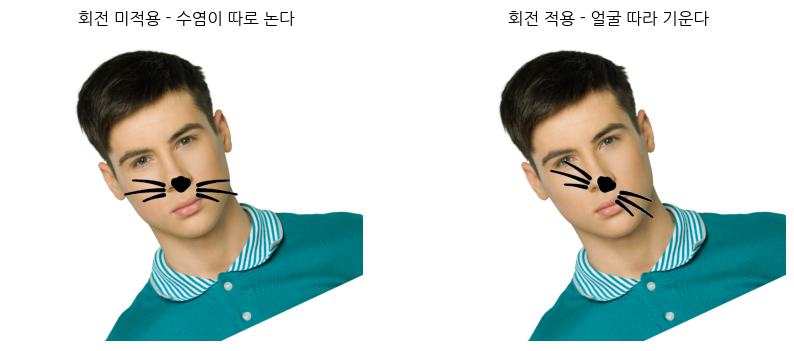

In [178]:
# [셀 목적] 기준 사진을 25도 기울여, 수염 회전 '미적용 vs 적용'을 나란히 비교한다.
tilted = rotate_image(cv2.imread(base_path), 25)     # rotate_image 는 9-4(41번)에서 정의함
tmp = os.path.join(os.getcwd(), 'images', '_tmp_tilt.png')
cv2.imwrite(tmp, tilted)

before, _ = add_cat_whiskers(tmp, sticker_path, detector_hog, landmark_predictor)        # 회전 미적용(수염 똑바로)
after,  _ = add_whiskers_rotated(tmp, sticker_path, detector_hog, landmark_predictor)     # 회전 적용(수염도 기울임)
os.remove(tmp)                                       # _ 는 '안 쓰는 값(얼굴 수)'을 버리는 자리

fig, ax = plt.subplots(1, 2, figsize=(10, 5))        # 그림 1행 2칸(왼=before, 오=after)
ax[0].imshow(cv2.cvtColor(before, cv2.COLOR_BGR2RGB))
ax[0].set_title('회전 미적용 - 수염이 따로 논다'); ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(after, cv2.COLOR_BGR2RGB))
ax[1].set_title('회전 적용 - 얼굴 따라 기운다'); ax[1].axis('off')
plt.show()

## 12. 추가로 연구해 볼 만한 것

기본 과제를 넘어서 더 파보면 좋을 것들을 적어 둔다(다음에 시도).

1. **얼굴 크기에 맞춘 스티커 비율**: 지금은 스티커를 정사각(얼굴 폭)으로 키우는데, 수염 원본 비율을 살려 가로만 얼굴 폭에 맞추면 덜 찌그러진다.
2. **알파 채널 스티커 비교**: 흰 배경 `==255` 크로마키 대신, 투명(RGBA) PNG 를 받아 알파 채널로 합성하면 경계가 더 깔끔한지 비교.
3. **옆얼굴 검출기**: `dlib.cnn_face_detection_model_v1` 같은 모델로 옆얼굴도 잡히는지, 속도는 얼마나 느려지는지 측정.
4. **밝기 보정 전처리**: 어두운 사진에 히스토그램 평활화(`cv2.equalizeHist`)를 먼저 걸면 검출률이 오르는지 실험.
5. **여러 스티커 동시 적용**: 수염 + 귀 + 코를 한 번에 올려 진짜 고양이 필터처럼 만들기.


## 13. 결과 요약과 회고

### 실험 결과 요약 (실행 후 숫자 채움)

| 실험 | 변수 | 결과(얼굴 검출/합성) | 알게 된 점 |
|------|------|----------------------|-----------|
| 기준 사진 front | 정면·보통밝기 | 얼굴 1개, 수염 코에 정상 | 파이프라인 정상 동작 |
| 회전 0~90도 | 각도 | 0~45도 검출, 60·90도 실패 | 정면 탐지기는 많이 기운 얼굴 못 잡음 |
| 밝기 0.05~5.0배 | 밝기 | 0.1~3.0배 검출, 0.05↓·5.0 실패 | HOG는 균일 밝기엔 강함(기울기 기반) |
| 대비 1.0~0.03배 | 대비 | 0.05배까지 검출, 0.03 실패 | 대비엔 강건, 거의 평평해져야 실패 |
| 축소 1.0~0.05배 | 거리 | 가로 96px까지 검출, 60px↓ 실패 | 얼굴이 너무 작으면 검출 실패 |
| 실제사진 front·child | 정면 | 둘 다 검출 1개, 수염 정상 | 사람 달라도 정면이면 잘 됨 |
| 실제사진 side(옆얼굴) | 각도 | 검출 0개, 수염 안 붙음 | 정면 탐지기는 프로필 못 잡음 |
| 실제사진 tilt(기울임+가림) | 각도·가림 | 검출 0개, 수염 안 붙음 | 각도에 가림까지 겹치면 실패 |
| 실제사진 group(여러 명) | 다중 얼굴 | 검출 4개, 전원 수염 | for문이 박스 여러 개 처리 |

### 회고
- 노드(왕관)를 고양이 수염으로 바꿀 때 핵심은 딱 두 군데였다  
   — **코(33번)에 두기**, 그리고 배경이 흰색이라 **`np.where` 조건을 `==255`로 뒤집기**. 배경색에 따라 합성 조건이 달라진다는 걸 확실히 이해했다.
- `np.where` 합성이 진짜 투명(알파)이 아니라 **특정 색을 투명 취급하는 크로마키**라는 걸 이해하니, 왜 배경색이 중요한지 납득이 됐다.
- Step 5 실험에서 가장 크게 배운 건, 이 앱의 한계가 대부분 **정면 얼굴 탐지기**에서 온다는 점이다(옆얼굴·작은 얼굴·회전에서 검출이 깨짐).  
   위치 계산보다 **검출 단계가 전체 성패를 좌우**한다.
- "비스듬한 얼굴엔 못 그리나?" 하는 궁금증을 11번에서 직접 회전 구현으로 풀었다.  
   막상 해보니 어려운 건 회전 자체가 아니라 **부호(이미지 y축이 아래로 +라 헷갈림)와 빈 모서리 색(흰색으로 채워야 함)** 같은 디테일이었다.  
   머리로 추측 말고 둘 다 그려서 비교하니 금방 정해졌다.
- 다만 완전 옆얼굴은 회전으로도 안 된다는 것(검출 자체가 0)도 같이 확인했다. 다음엔 옆얼굴 검출기를 붙여보고 싶다.


## 14. 참고자료 (레퍼런스)

이 프로젝트에서 쓴 도구와 알고리즘의 출처를 모았다. 더 깊이 보고 싶을 때 참고용.

**dlib (얼굴 검출 + 랜드마크)**
- dlib 공식 얼굴 검출 예제: http://dlib.net/face_detector.py.html  (`detector(img, 1)` 의 두번째 인자 = 업샘플 횟수라는 게 여기 설명돼 있다. 9-5에서 0/1/2로 바꿔 시간을 잰 그 숫자.)
- dlib 공식 68점 랜드마크 예제: http://dlib.net/face_landmark_detection.py.html
- dlib 소스코드(GitHub): https://github.com/davisking/dlib

**알고리즘 논문**
- 얼굴 검출(HOG 방식): N. Dalal & B. Triggs, "Histograms of Oriented Gradients for Human Detection", CVPR 2005.
- 68점 랜드마크(shape_predictor 가 쓰는 알고리즘): V. Kazemi & J. Sullivan, "One Millisecond Face Alignment with an Ensemble of Regression Trees", CVPR 2014.
- 68점 번호 규칙(어느 점이 코·눈·입인지): iBUG 300-W 얼굴 랜드마크 주석 - https://ibug.doc.ic.ac.uk/resources/facial-point-annotations/

**라이브러리 문서**
- OpenCV(cv2): https://docs.opencv.org/  (cv2.imread, cv2.rectangle, cv2.circle, cv2.resize, cv2.warpAffine, cv2.copyMakeBorder, cv2.cvtColor)
- NumPy: https://numpy.org/doc/  (np.where 로 배경을 투명 취급해 합성)

**모델 파일**
- 68점 랜드마크 모델: http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2  (1b 셀에서 없으면 자동 다운로드)

> 이 프로젝트 자체는 아이펠 노드(`node_study.ipynb`, 왕관 버전)를 바탕으로, 고양이 수염 버전으로 바꿔 만든 것이다.